In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [3]:
import pandas as pd

df = pd.read_csv(
    "twitter_training.csv",
    header=None
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (74682, 4)


,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nSentiment labels:")
print(df["Sentiment"].value_counts(dropna=False))

Column names:
['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB

Sentiment labels:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [5]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing tweet text or sentiment
df = df.dropna(subset=["Tweet", "Sentiment"]).copy()

# Remove duplicate rows
df = df.drop_duplicates()

# Keep only the three required sentiment classes
df["Sentiment"] = df["Sentiment"].str.lower().str.strip()

df = df[df["Sentiment"].isin(["positive", "negative", "neutral"])].copy()

# Reset row numbers
df = df.reset_index(drop=True)

print("\nDataset shape after cleaning:", df.shape)
print("\nSentiment counts:")
print(df["Sentiment"].value_counts())

Missing values before cleaning:
Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

Dataset shape after cleaning: (59119, 4)

Sentiment counts:
Sentiment
negative    21698
positive    19713
neutral     17708
Name: count, dtype: int64


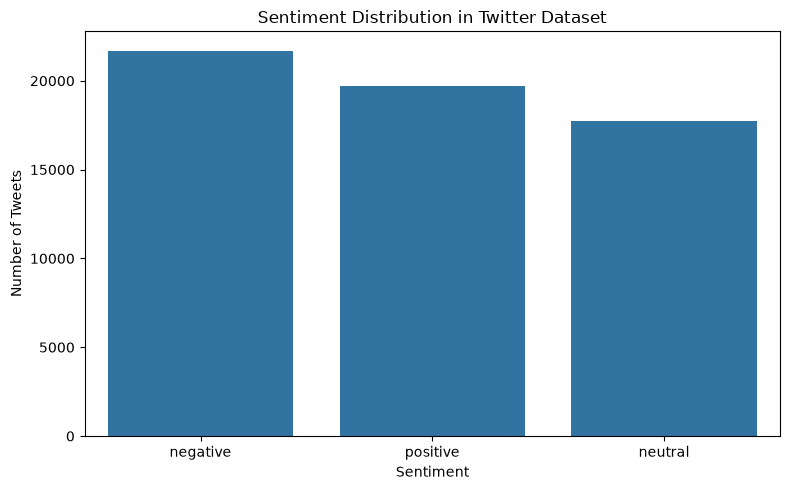

In [6]:
# Count each sentiment
sentiment_counts = df["Sentiment"].value_counts()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution in Twitter Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

In [7]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

print("Original tweet:")
print(df["Tweet"].iloc[0])

print("\nCleaned tweet:")
print(df["Clean_Tweet"].iloc[0])

Original tweet:
im getting on borderlands and i will murder you all ,

Cleaned tweet:
im getting on borderlands and i will murder you all


In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df["Processed_Tweet"] = df["Clean_Tweet"].apply(preprocess_text)

print("Original cleaned text:")
print(df["Clean_Tweet"].iloc[0])

print("\nAfter stopword removal:")
print(df["Processed_Tweet"].iloc[0])

Original cleaned text:
im getting on borderlands and i will murder you all

After stopword removal:
im getting borderlands murder


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["Processed_Tweet"]
y = df["Sentiment"]

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF conversion completed!")
print("Number of tweets:", X_tfidf.shape[0])
print("Number of features:", X_tfidf.shape[1])

TF-IDF conversion completed!
Number of tweets: 59119
Number of features: 5000


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Processed_Tweet"],
    df["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["Sentiment"]
)

# Learn vocabulary from training text only
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training and testing split completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("TF-IDF features:", X_train.shape[1])

Training and testing split completed!
Training samples: 47295
Testing samples: 11824
TF-IDF features: 5000


In [11]:
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict sentiment for test tweets
nb_predictions = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")
print("First 10 predictions:")
print(nb_predictions[:10])

Naive Bayes model trained successfully!
First 10 predictions:
['positive' 'negative' 'positive' 'neutral' 'negative' 'positive'
 'negative' 'positive' 'neutral' 'neutral']


In [12]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Predict sentiment for test tweets
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")
print("First 10 predictions:")
print(lr_predictions[:10])

Logistic Regression model trained successfully!
First 10 predictions:
['positive' 'negative' 'positive' 'neutral' 'negative' 'positive'
 'negative' 'positive' 'neutral' 'neutral']


In [1]:
from sklearn.metrics import accuracy_score, classification_report

print("===== NAIVE BAYES RESULTS =====")
print("Accuracy:", round(accuracy_score(y_test, nb_predictions), 4))
print("\nClassification Report:")
print(classification_report(y_test, nb_predictions, zero_division=0))

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", round(accuracy_score(y_test, lr_predictions), 4))
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions, zero_division=0))

===== NAIVE BAYES RESULTS =====


NameError: name 'y_test' is not defined

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Processed_Tweet"],
    df["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["Sentiment"]
)

tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Train/test split completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

NameError: name 'df' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

df = pd.read_csv("twitter_training.csv", header=None)
df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

df = df.dropna(subset=["Tweet", "Sentiment"]).copy()
df = df.drop_duplicates()
df["Sentiment"] = df["Sentiment"].str.lower().str.strip()
df = df[df["Sentiment"].isin(["positive", "negative", "neutral"])].copy()
df = df.reset_index(drop=True)

print("Dataset loaded successfully!")
print(df.shape)
print(df.head())

Dataset loaded successfully!
(59119, 4)
   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  positive   
1      2401  Borderlands  positive   
2      2401  Borderlands  positive   
3      2401  Borderlands  positive   
4      2401  Borderlands  positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)
df["Processed_Tweet"] = df["Clean_Tweet"].apply(preprocess_text)

print("Text preprocessing completed!")
print(df[["Tweet", "Processed_Tweet"]].head())

Text preprocessing completed!
                                               Tweet  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                 Processed_Tweet  
0  im getting borderlands murder  
1            coming borders kill  
2    im getting borderlands kill  
3   im coming borderlands murder  
4  im getting borderlands murder  


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Processed_Tweet"],
    df["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["Sentiment"]
)

tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Train/test split completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("TF-IDF features:", X_train.shape[1])

Train/test split completed!
Training samples: 47295
Testing samples: 11824
TF-IDF features: 5000


In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("Both models trained successfully!")
print("Naive Bayes predictions:", nb_predictions[:5])
print("Logistic Regression predictions:", lr_predictions[:5])

Both models trained successfully!
Naive Bayes predictions: ['positive' 'negative' 'positive' 'neutral' 'negative']
Logistic Regression predictions: ['positive' 'negative' 'positive' 'neutral' 'negative']


In [7]:
from sklearn.metrics import accuracy_score, classification_report

print("===== NAIVE BAYES RESULTS =====")
print("Accuracy:", round(accuracy_score(y_test, nb_predictions), 4))
print(classification_report(y_test, nb_predictions, zero_division=0))

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", round(accuracy_score(y_test, lr_predictions), 4))
print(classification_report(y_test, lr_predictions, zero_division=0))

===== NAIVE BAYES RESULTS =====
Accuracy: 0.7099
              precision    recall  f1-score   support

    negative       0.70      0.82      0.75      4340
     neutral       0.74      0.55      0.63      3541
    positive       0.71      0.73      0.72      3943

    accuracy                           0.71     11824
   macro avg       0.71      0.70      0.70     11824
weighted avg       0.71      0.71      0.71     11824


===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 0.7437
              precision    recall  f1-score   support

    negative       0.74      0.83      0.78      4340
     neutral       0.73      0.65      0.69      3541
    positive       0.76      0.74      0.75      3943

    accuracy                           0.74     11824
   macro avg       0.74      0.74      0.74     11824
weighted avg       0.74      0.74      0.74     11824



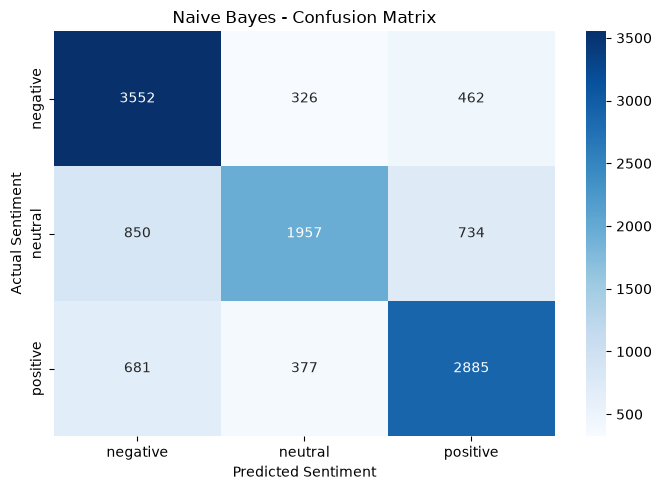

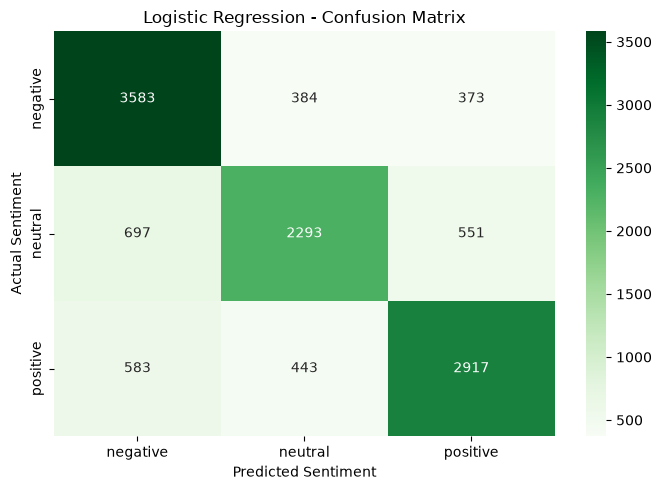

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["negative", "neutral", "positive"]

# Naive Bayes confusion matrix
nb_cm = confusion_matrix(y_test, nb_predictions, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    nb_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

# Logistic Regression confusion matrix
lr_cm = confusion_matrix(y_test, lr_predictions, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    lr_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=labels, yticklabels=labels
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [9]:
from wordcloud import WordCloud
print("WordCloud is ready!")

ModuleNotFoundError: No module named 'wordcloud'

In [11]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [12]:
from wordcloud import WordCloud
print("WordCloud is ready!")

WordCloud is ready!


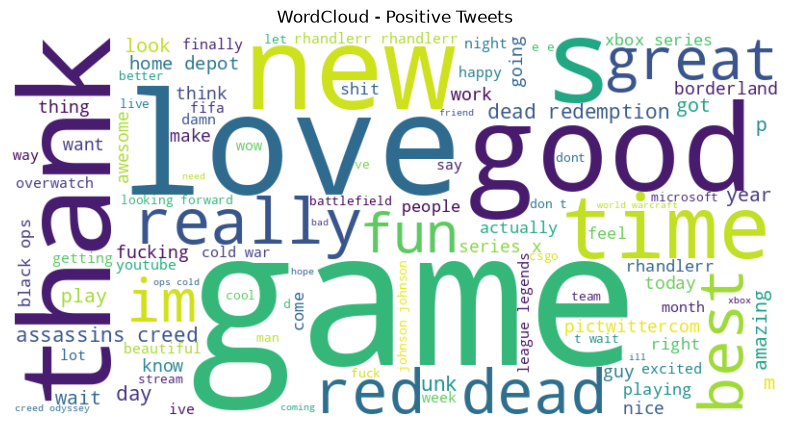

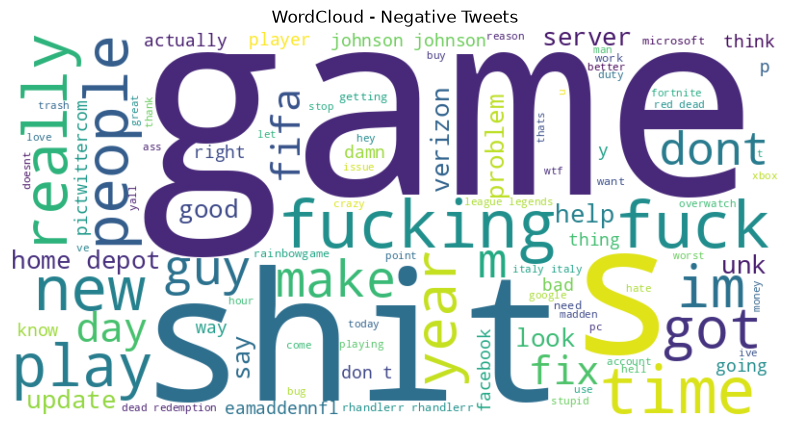

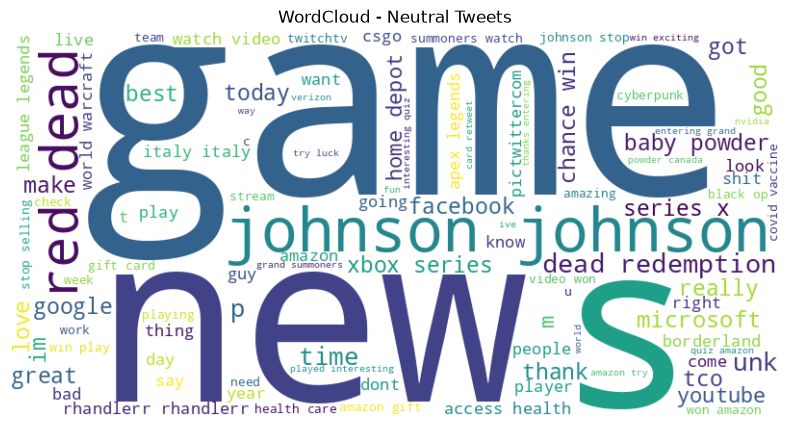

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sentiments = ["positive", "negative", "neutral"]

for sentiment in sentiments:
    text = " ".join(
        df.loc[df["Sentiment"] == sentiment, "Processed_Tweet"]
    )

    if text.strip():
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            max_words=100
        ).generate(text)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"WordCloud - {sentiment.title()} Tweets")
        plt.show()
    else:
        print(f"No tweets found for {sentiment}.")

In [14]:
error_analysis = pd.DataFrame({
    "Tweet": X_test_text.values,
    "Actual Sentiment": y_test.values,
    "Naive Bayes Prediction": nb_predictions,
    "Logistic Regression Prediction": lr_predictions
})

# Keep tweets misclassified by at least one model
errors = error_analysis[
    (error_analysis["Actual Sentiment"] != error_analysis["Naive Bayes Prediction"]) |
    (error_analysis["Actual Sentiment"] != error_analysis["Logistic Regression Prediction"])
]

print("Five misclassified examples:")
display(errors.head(5))

Five misclassified examples:


,Tweet,Actual Sentiment,Naive Bayes Prediction,Logistic Regression Prediction
3,ghost recon free download update ai teammates ...,positive,neutral,neutral
6,nvidia day like oh broken pictwittercomuklawquxd,positive,negative,negative
13,apple touch iphone plus includes gb jet black ...,neutral,neutral,positive
14,just faced terminator let tell scary hell,positive,negative,negative
16,dont understand hatred assassins creed,positive,negative,negative


,Model,Accuracy
0,Naive Bayes,0.709912
1,Logistic Regression,0.743657


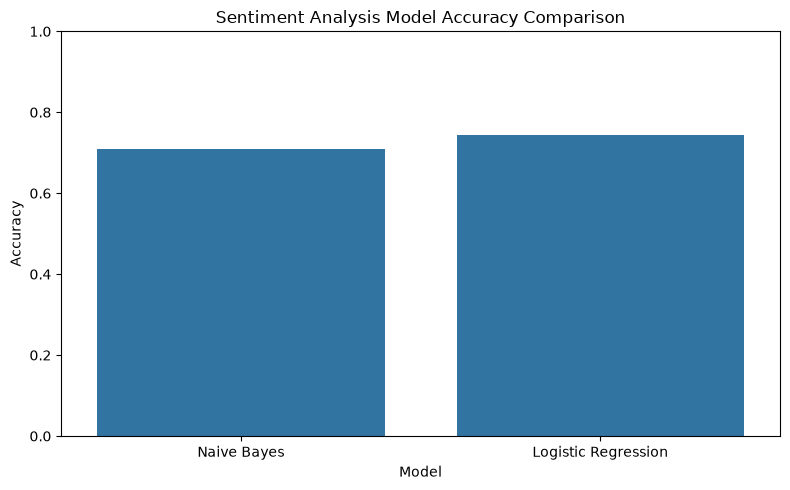

Best model based on accuracy: Logistic Regression


In [15]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
lr_accuracy = accuracy_score(y_test, lr_predictions)

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy]
})

display(comparison)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="Model", y="Accuracy")
plt.title("Sentiment Analysis Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

best_model = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]
print("Best model based on accuracy:", best_model)

1. TF-IDF Vectorization

TF-IDF stands for Term Frequency–Inverse Document Frequency. It converts text into numerical features that machine learning models can understand.

- Term Frequency (TF): Measures how frequently a word appears in a tweet.
- Inverse Document Frequency (IDF): Reduces the importance of words that appear across many documents.
- Purpose: TF-IDF helps represent the importance of words in tweets for sentiment classification.

In this project, "TfidfVectorizer" converts the processed tweets into numerical features. It is fitted on the training data only to avoid data leakage.

2. Project Methodology

Dataset

The project uses the Twitter Entity Sentiment Analysis dataset, containing tweets labelled with sentiment categories.

Data Cleaning

- Removed rows with missing tweets or sentiment labels.
- Removed duplicate records.
- Standardized sentiment labels to lowercase.
- Selected positive, negative, and neutral tweets for this three-class classification task.

Text Preprocessing

- Converted text to lowercase.
- Removed URLs, mentions, punctuation, and numbers.
- Removed common English stopwords.
- Prepared processed tweets for machine learning.

Model Development

- Split the data into 80% training data and 20% testing data.
- Converted tweets into TF-IDF features.
- Trained two classifiers: Multinomial Naive Bayes and Logistic Regression.

Model Evaluation

Evaluated both models using accuracy, precision, recall, F1-score, and confusion matrices. WordCloud visualizations were created to explore common words in each sentiment category.

3. Conclusion and Real-World Applications

This project developed a three-class sentiment analysis system to classify tweets as positive, negative, or neutral.

The dataset was cleaned and preprocessed before TF-IDF vectorization. Two machine learning algorithms, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using an 80/20 train-test split.

The models were compared using accuracy, precision, recall, F1-score, and confusion matrices. The model with the better evaluation results can be selected for further use.

Real-World Applications

- Customer feedback: Understand customer opinions about products and services.
- Brand monitoring: Track public sentiment about a company or brand.
- Social media analysis: Identify positive, negative, and neutral opinions.
- Product improvement: Discover common complaints and customer preferences.

Limitations

Tweets may contain sarcasm, slang, spelling mistakes, or context-dependent meanings that are difficult for traditional machine learning models to interpret correctly.